# House Prices Prediction

This notebook predicts house prices for the Kaggle competition **House Prices - Advanced Regression Techniques**.

The code is kept as simple as possible, but the final model logic is the same conservative blend that gave the better score.  
Only extra exploratory cells were removed. The preprocessing, feature engineering, models, and blend weights were kept unchanged to protect the Kaggle score.

# **Importing**


In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.special import boxcox1p

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, ElasticNet, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42

In [26]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/ColabNotebooks/House-Prices

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ColabNotebooks/House-Prices


# **Load Data**

In [27]:
tr_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/House-Prices/input/train.csv')
te_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/House-Prices/input/test.csv')

tr_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **Dataset Overview**

Before modeling, we quickly check the target column, missing values, and the strongest numeric relationships with `SalePrice`.

In [28]:
tr_df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [29]:
missing = tr_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({'Missing Count': missing, 'Missing Percent': (missing / len(tr_df) * 100).round(2)})

missing_table.head(20)

,Missing Count,Missing Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


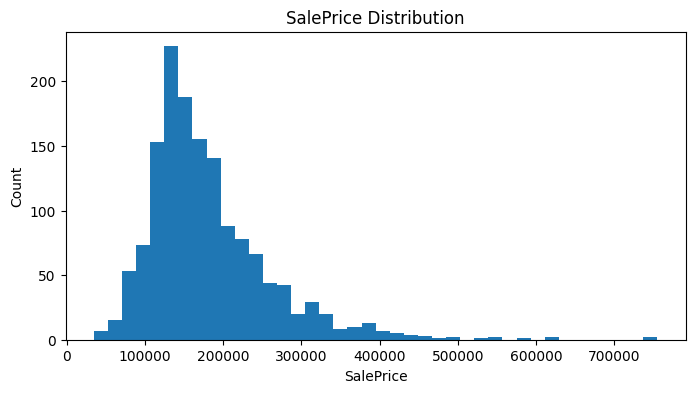

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(tr_df['SalePrice'], bins=40)
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()

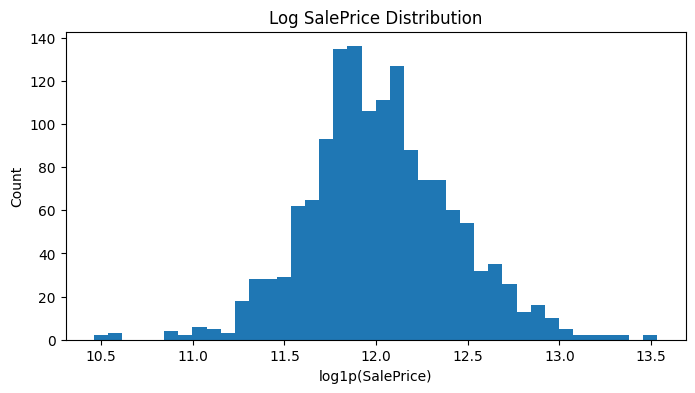

In [31]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(tr_df['SalePrice']), bins=40)
plt.title('Log SalePrice Distribution')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Count')
plt.show()

In [32]:
corr = tr_df.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)
corr.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


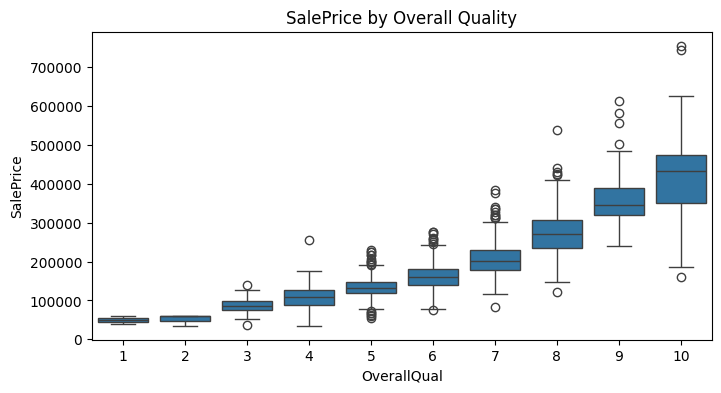

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=tr_df)
plt.title('SalePrice by Overall Quality')
plt.show()

### More EDA Charts

These charts help us understand the data before modeling. They do not change the final model or the Kaggle score.


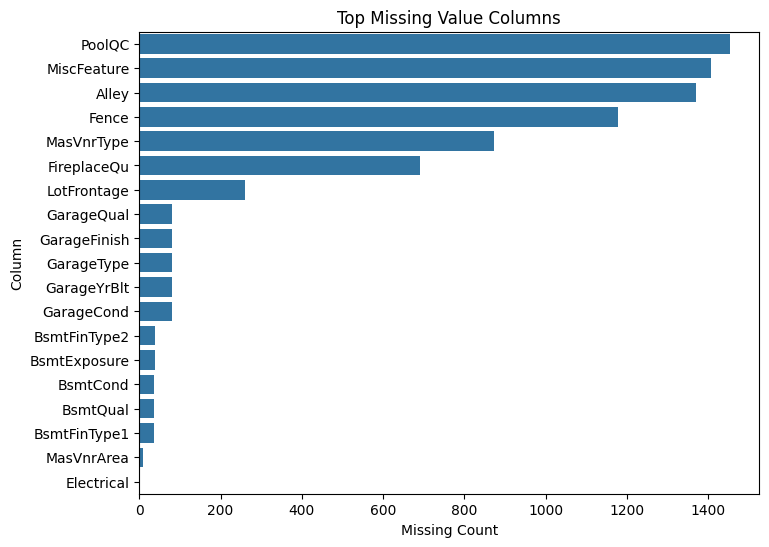

In [34]:
missing_top = tr_df.isnull().sum().sort_values(ascending=False).head(20)
missing_top = missing_top[missing_top > 0]

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_top.values, y=missing_top.index)
plt.title('Top Missing Value Columns')
plt.xlabel('Missing Count')
plt.ylabel('Column')
plt.show()

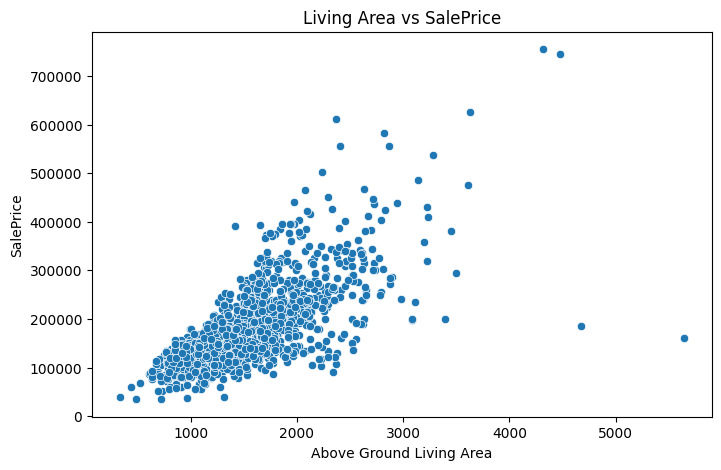

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=tr_df)
plt.title('Living Area vs SalePrice')
plt.xlabel('Above Ground Living Area')
plt.ylabel('SalePrice')
plt.show()

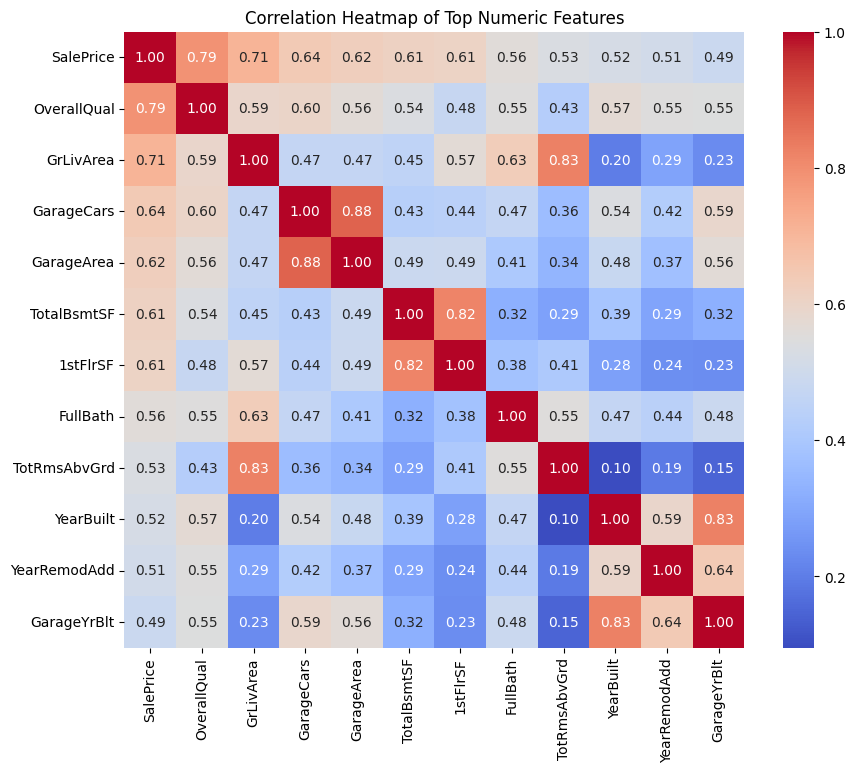

In [36]:
top_corr_cols = corr.head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(tr_df[top_corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Top Numeric Features')
plt.show()

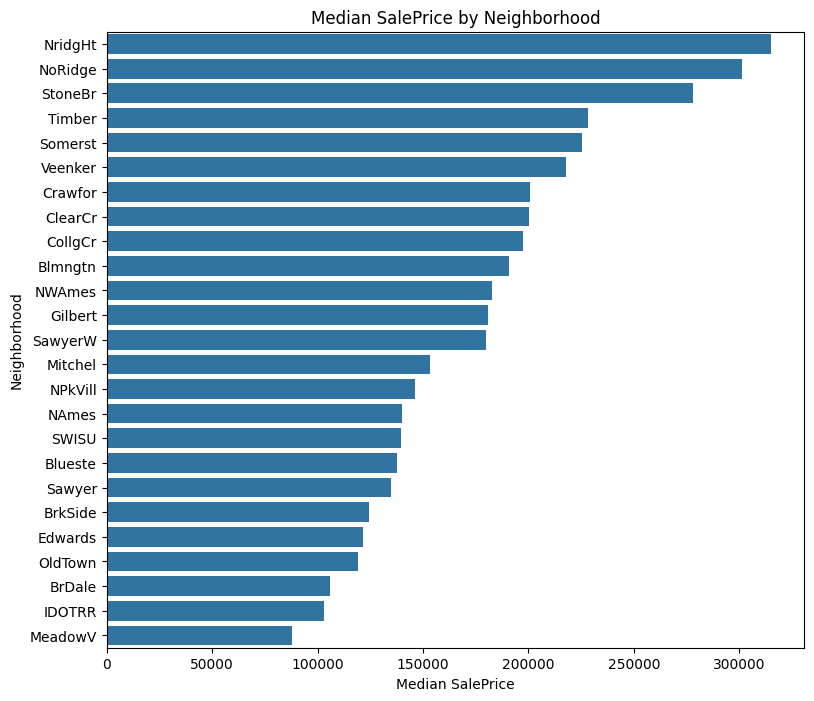

In [37]:
neighborhood_price = tr_df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
plt.figure(figsize=(9, 8))
sns.barplot(x=neighborhood_price.values, y=neighborhood_price.index)
plt.title('Median SalePrice by Neighborhood')
plt.xlabel('Median SalePrice')
plt.ylabel('Neighborhood')
plt.show()

## 4. Main Modeling Pipeline

From this point, the model pipeline is the important part.  
These steps are kept the same as the conservative version:

1. Remove famous outliers
2. Apply `log1p` to `SalePrice`
3. Handle missing values correctly
4. Create useful new features
5. Encode categorical columns
6. Train several models
7. Blend their predictions with fixed conservative weights

Fresh copies for final modeling

In [38]:
train = tr_df.copy()
test = te_df.copy()
test_id = test['Id'].copy()

Remove famous outliers

In [39]:
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index).reset_index(drop=True)

In [40]:
y = np.log1p(train['SalePrice']).values

all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)
all_data = all_data.drop('Id', axis=1)

print('Train after outlier removal:', train.shape)
print('Combined data shape:', all_data.shape)

Train after outlier removal: (1458, 81)
Combined data shape: (2917, 79)


# **Missing Values**

Some missing values mean that the house does not have that feature.  
For example, missing garage columns usually mean **No Garage**, not a real data error.

In [41]:
# Missing categorical values where NA means the feature does not exist
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# Missing numeric values where zero is meaningful
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage is filled by the median of each Neighborhood
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

# Other real missing categorical values
for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

if 'Functional' in all_data.columns:
    all_data['Functional'] = all_data['Functional'].fillna('Typ')

# Utilities is almost constant, so we remove it
if 'Utilities' in all_data.columns:
    all_data = all_data.drop('Utilities', axis=1)

# Fill anything still missing
for col in all_data.select_dtypes(exclude='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].median())

for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print('Remaining missing values:', all_data.isnull().sum().sum())

Remaining missing values: 0


### Encoding Ordered Columns

Some categories have a clear order.  
For example, `Ex` is better than `Gd`, and `Gd` is better than `TA`.

In [42]:
# These columns are numbers, but they represent categories
for col in ['MSSubClass', 'MoSold', 'YrSold']:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype(str)

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0).astype(int)

ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'CentralAir': {'N': 0, 'Y': 1},
    'Fence': {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
}

for col, mapping in ordinal_maps.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping).fillna(0).astype(int)

### Feature Engineering

We create simple but useful features such as total area, total bathrooms, house age, and whether the house has a garage, basement, pool, or fireplace.

In [43]:
YrSold_int = all_data['YrSold'].astype(int)

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']

all_data['HouseAge'] = YrSold_int - all_data['YearBuilt']
all_data['RemodAge'] = YrSold_int - all_data['YearRemodAdd']
all_data['GarageAge'] = np.where(all_data['GarageYrBlt'] > 0, YrSold_int - all_data['GarageYrBlt'], 0)

all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew'] = (all_data['YearBuilt'] == YrSold_int).astype(int)

all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBasement'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasWoodDeck'] = (all_data['WoodDeckSF'] > 0).astype(int)
all_data['HasOpenPorch'] = (all_data['OpenPorchSF'] > 0).astype(int)
all_data['HasMasVnr'] = (all_data['MasVnrArea'] > 0).astype(int)

all_data['TotalQual'] = all_data['OverallQual'] + all_data['OverallCond']
all_data['QualSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['QualGrLiv'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['QualBath'] = all_data['OverallQual'] * all_data['TotalBath']
all_data['QualGarage'] = all_data['OverallQual'] * all_data['GarageCars']
all_data['BsmtQualSF'] = all_data['BsmtQual'] * all_data['TotalBsmtSF']
all_data['GarageQualArea'] = all_data['GarageQual'] * all_data['GarageArea']
all_data['KitchenQualSF'] = all_data['KitchenQual'] * all_data['TotalSF']
all_data['ExterQualSF'] = all_data['ExterQual'] * all_data['TotalSF']

/tmp/ipykernel_1008/318856053.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_data['GarageQualArea'] = all_data['GarageQual'] * all_data['GarageArea']
/tmp/ipykernel_1008/318856053.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_data['KitchenQualSF'] = all_data['KitchenQual'] * all_data['TotalSF']
/tmp/ipykernel_1008/318856053.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

### Skewed Features and One-Hot Encoding

Some numeric columns are highly skewed. We reduce this problem using Box-Cox.  
Then we convert the remaining text columns into numeric dummy columns.

In [44]:
numeric_features = all_data.dtypes[all_data.dtypes != 'object'].index
skew_values = all_data[numeric_features].apply(lambda x: skew(x.dropna()))
skewed_features = skew_values[abs(skew_values) > 0.75].index

for col in skewed_features:
    if all_data[col].min() < 0:
        all_data[col] = all_data[col] - all_data[col].min()
    all_data[col] = boxcox1p(all_data[col], 0.15)

all_data = pd.get_dummies(all_data)

n_train = len(train)
X = all_data.iloc[:n_train].copy()
X_test = all_data.iloc[n_train:].copy()

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

print('Final train shape:', X.shape)
print('Final test shape :', X_test.shape)
print('Number of transformed skewed features:', len(skewed_features))

Final train shape: (1458, 277)
Final test shape : (1459, 277)
Number of transformed skewed features: 47


# **Models and Conservative Blend**

The final prediction is made by blending several models.  
This is why the score is usually better than using only one model.

The weights below are kept from the better conservative submission, so changing them may change the Kaggle score.

In [45]:
models = {
    'lasso': make_pipeline(
        RobustScaler(),
        Lasso(alpha=0.00042, random_state=RANDOM_STATE, max_iter=20000)
    ),
    'enet': make_pipeline(
        RobustScaler(),
        ElasticNet(alpha=0.00048, l1_ratio=0.86, random_state=RANDOM_STATE, max_iter=20000)
    ),
    'ridge': make_pipeline(
        RobustScaler(),
        Ridge(alpha=9.0, random_state=RANDOM_STATE)
    ),
    'krr': make_pipeline(
        RobustScaler(),
        KernelRidge(alpha=0.60, kernel='polynomial', degree=2, coef0=2.5)
    ),
    'gbr': GradientBoostingRegressor(
        n_estimators=900,
        learning_rate=0.035,
        max_depth=4,
        max_features='sqrt',
        min_samples_leaf=15,
        min_samples_split=10,
        loss='huber',
        random_state=RANDOM_STATE
    ),
    'xgb': XGBRegressor(
        n_estimators=900,
        learning_rate=0.025,
        max_depth=3,
        min_child_weight=2,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=0.0004,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbosity=0
    ),
    'lgbm': LGBMRegressor(
        objective='regression',
        num_leaves=5,
        learning_rate=0.025,
        n_estimators=1100,
        max_bin=90,
        bagging_fraction=0.8,
        bagging_freq=5,
        feature_fraction=0.25,
        min_data_in_leaf=6,
        min_sum_hessian_in_leaf=11,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1
    )
}

weights = {
    'lasso': 0.16880338552954197,
    'enet': 0.16718708540685231,
    'ridge': 0.04701030923263547,
    'krr': 0.19149982997569610,
    'gbr': 0.14500010018665793,
    'xgb': 0.14849726451308384,
    'lgbm': 0.13200202515553244
}

# **Cross Validation**

Cross Validation checks how well each model performs on different parts of the training data.  
This section is only for evaluation. It does not change the final submission logic.


In [46]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rmse_cv(model):
    scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
    return np.sqrt(-scores)

cv_results = []

for name, model in models.items():
    scores = rmse_cv(model)
    cv_results.append({
        'Model': name,
        'Mean RMSE': scores.mean(),
        'Std RMSE': scores.std()
    })
    print(f'{name}: {scores.mean():.5f} (+/- {scores.std():.5f})')

cv_results_df = pd.DataFrame(cv_results).sort_values('Mean RMSE')
cv_results_df


lasso: 0.11067 (+/- 0.00684)
enet: 0.11068 (+/- 0.00689)
ridge: 0.11245 (+/- 0.00828)
krr: 0.11883 (+/- 0.00444)
gbr: 0.11226 (+/- 0.00783)
xgb: 0.11417 (+/- 0.00633)
lgbm: 0.11863 (+/- 0.00871)


,Model,Mean RMSE,Std RMSE
0,lasso,0.110670,0.006842
1,enet,0.110675,0.006886
4,gbr,0.112264,0.007826
2,ridge,0.112447,0.008279
5,xgb,0.114169,0.006329
6,lgbm,0.118632,0.008713
3,krr,0.118834,0.004443


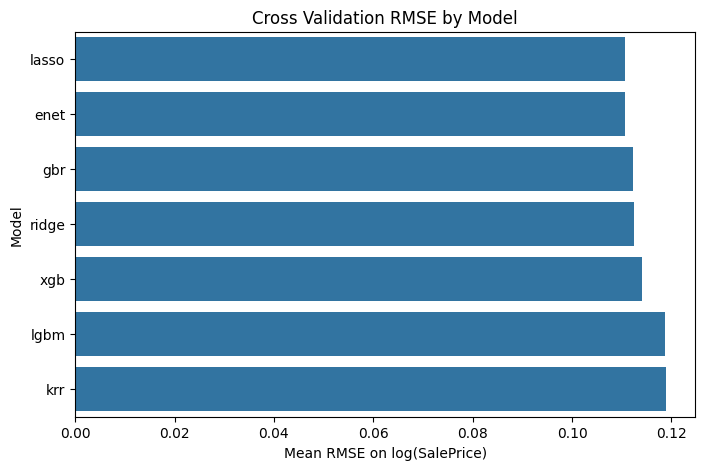

In [47]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Mean RMSE', y='Model', data=cv_results_df)
plt.title('Cross Validation RMSE by Model')
plt.xlabel('Mean RMSE on log(SalePrice)')
plt.ylabel('Model')
plt.show()


# **Train Models and Create Submission**

Each model predicts the log price.  
Then we combine all predictions using the fixed conservative weights and convert the result back to normal price values.

In [48]:
log_predictions = {}

for name, model in models.items():
    print('Training:', name)
    model.fit(X, y)
    log_predictions[name] = model.predict(X_test)

final_log_prediction = np.zeros(len(X_test))

for name, weight in weights.items():
    final_log_prediction += weight * log_predictions[name]

final_prediction = np.expm1(final_log_prediction)
final_prediction = np.maximum(final_prediction, 0)

submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_prediction
})

submission.to_csv('output/submission_final.csv', index=False)
submission.head()

Training: lasso
Training: enet
Training: ridge
Training: krr
Training: gbr
Training: xgb
Training: lgbm


,Id,SalePrice
0,1461,120418.002854
1,1462,162026.637057
2,1463,178150.943543
3,1464,195656.987076
4,1465,192309.181090


# **Conclusion**

In this project, we built a regression model to predict house prices.  
The most important work was not only choosing a model, but also preparing the data correctly.

Main points:

- `SalePrice` was log-transformed because house prices are skewed.
- Missing values were handled based on their real meaning.
- Important new features were created, such as `TotalSF`, `TotalBath`, `HouseAge`, and `HasGarage`.
- Several models were trained and blended together.
- The final submission uses the conservative blend because it gave the better Kaggle score compared with the simpler version.

This final notebook is cleaner than the previous version, but it keeps the same modeling logic to avoid reducing the score.